In [1]:
# You need the following functions (copy them)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Q1: Load the penguins dataset from seaborn into df and display first 5 rows
df = sns.load_dataset("penguins")
print("Q1) First 5 rows:")
display(df.head())

Q1) First 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
# Q2: Print shape, column names, data types
print("\nQ2) Dataset shape:", df.shape)
print("\nQ2) Column names:")
print(df.columns.tolist())
print("\nQ2) Data types:")
print(df.dtypes)


Q2) Dataset shape: (344, 7)

Q2) Column names:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Q2) Data types:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


In [4]:
# Q3: Check missing values in each column
print("\nQ3) Missing values per column:")
print(df.isna().sum())


Q3) Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [5]:
# Q4: Create df_clean:
# 1) Drop duplicates
# 2) Fill missing values: numeric->median, categorical->mode
df_clean = df.copy()

# 1) Drop duplicates
df_clean = df_clean.drop_duplicates()

# 2) Fill missing values
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    # mode() can return multiple values; take the first
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode(dropna=True)[0])

print("\nQ4) After cleaning - missing values per column:")
print(df_clean.isna().sum())


Q4) After cleaning - missing values per column:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [6]:
# Part B: Filtering, Sorting, Aggregation
# -------------------------

# Q5: Filter only island == "Biscoe" into biscoe_df and print shape
biscoe_df = df_clean[df_clean["island"] == "Biscoe"].copy()
print("\nQ5) biscoe_df shape:", biscoe_df.shape)


Q5) biscoe_df shape: (168, 7)


In [7]:
# Q6: Find penguins with body_mass_g > overall mean AND sex == "Male"
overall_mean_mass = df_clean["body_mass_g"].mean()
heavy_males = df_clean[(df_clean["body_mass_g"] > overall_mean_mass) & (df_clean["sex"] == "Male")].copy()

print("\nQ6) heavy_males first 5 rows:")
display(heavy_males.head())


Q6) heavy_males first 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,Male
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male
17,Adelie,Torgersen,42.5,20.7,197.0,4500.0,Male
39,Adelie,Dream,39.8,19.1,184.0,4650.0,Male


In [8]:
# Q7: Sort df_clean by body_mass_g desc, then bill_length_mm asc; show top 10
sorted_df = df_clean.sort_values(by=["body_mass_g", "bill_length_mm"], ascending=[False, True])
print("\nQ7) Top 10 sorted rows:")
display(sorted_df.head(10))


Q7) Top 10 sorted rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
237,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,Male
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,Male
297,Gentoo,Biscoe,51.1,16.3,220.0,6000.0,Male
299,Gentoo,Biscoe,45.2,16.4,223.0,5950.0,Male
331,Gentoo,Biscoe,49.8,15.9,229.0,5950.0,Male
233,Gentoo,Biscoe,48.4,14.6,213.0,5850.0,Male
235,Gentoo,Biscoe,49.3,15.7,217.0,5850.0,Male
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,Male
295,Gentoo,Biscoe,48.6,16.0,230.0,5800.0,Male


In [9]:
# Q8: Aggregations
# 1) Mean body_mass_g per species (desc)
mean_mass_per_species = df_clean.groupby("species")["body_mass_g"].mean().sort_values(ascending=False)

# 2) Mean bill_length_mm per (species, sex)
mean_billlen_species_sex = df_clean.groupby(["species", "sex"])["bill_length_mm"].mean()

# 3) Count per island
count_per_island = df_clean["island"].value_counts()

print("\nQ8.1) Mean body_mass_g per species (desc):")
display(mean_mass_per_species)

print("\nQ8.2) Mean bill_length_mm per (species, sex):")
display(mean_billlen_species_sex)

print("\nQ8.3) Count of records per island:")
display(count_per_island)


Q8.1) Mean body_mass_g per species (desc):


species
Gentoo       5067.741935
Chinstrap    3733.088235
Adelie       3702.960526
Name: body_mass_g, dtype: float64


Q8.2) Mean bill_length_mm per (species, sex):


species    sex   
Adelie     Female    37.257534
           Male      40.280380
Chinstrap  Female    46.573529
           Male      51.094118
Gentoo     Female    45.563793
           Male      49.164394
Name: bill_length_mm, dtype: float64


Q8.3) Count of records per island:


island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [10]:
# Q9: Feature engineering bill_ratio = bill_length_mm / bill_depth_mm
df_clean["bill_ratio"] = df_clean["bill_length_mm"] / df_clean["bill_depth_mm"]

print("\nQ9.2) Summary stats for bill_ratio:")
display(df_clean["bill_ratio"].describe())

bill_ratio_by_species = df_clean.groupby("species")["bill_ratio"].mean().sort_values(ascending=False)
print("\nQ9.3) Species with highest avg bill_ratio:")
display(bill_ratio_by_species)
print("Highest avg bill_ratio species:", bill_ratio_by_species.index[0])


Q9.2) Summary stats for bill_ratio:


count    344.000000
mean       2.605438
std        0.495930
min        1.639810
25%        2.161882
50%        2.571484
75%        3.097572
max        3.612676
Name: bill_ratio, dtype: float64


Q9.3) Species with highest avg bill_ratio:


species
Gentoo       3.170703
Chinstrap    2.653756
Adelie       2.122684
Name: bill_ratio, dtype: float64

Highest avg bill_ratio species: Gentoo


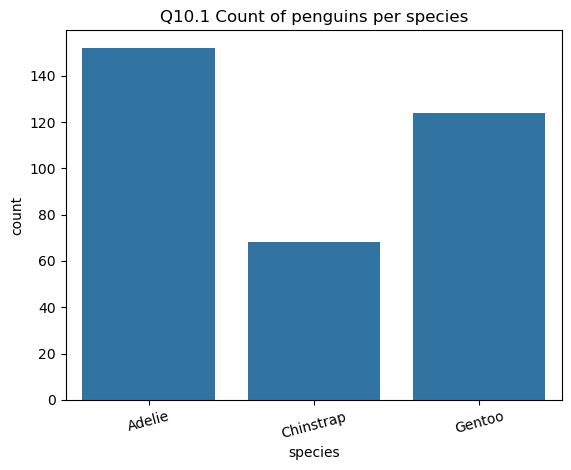

In [11]:
# Q10.1: Bar plot count of penguins per species
plt.figure()
sns.countplot(data=df_clean, x="species")
plt.title("Q10.1 Count of penguins per species")
plt.xticks(rotation=15)
plt.show()


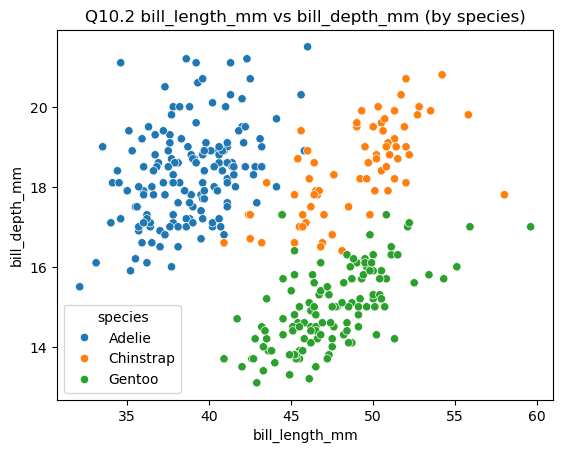

In [12]:
# Q10.2: Scatter bill_length_mm vs bill_depth_mm (color by species)
plt.figure()
sns.scatterplot(data=df_clean, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.title("Q10.2 bill_length_mm vs bill_depth_mm (by species)")
plt.show()

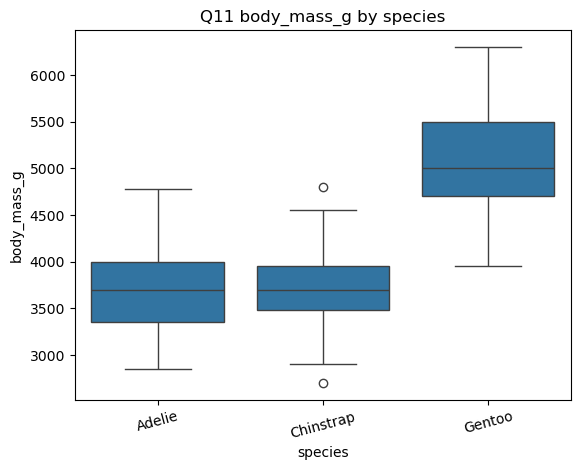

In [13]:
# Q11: Box plot body_mass_g by species + interpretation
plt.figure()
sns.boxplot(data=df_clean, x="species", y="body_mass_g")
plt.title("Q11 body_mass_g by species")
plt.xticks(rotation=15)
plt.show()


In [ ]:
Gentoo penguins have a significantly higher median body mass compared to Adelie and Chinstrap, making them the heaviest species overall. 
Adelie and Chinstrap have similar median weights, but Chinstrap shows slightly more variability and a few outliers.

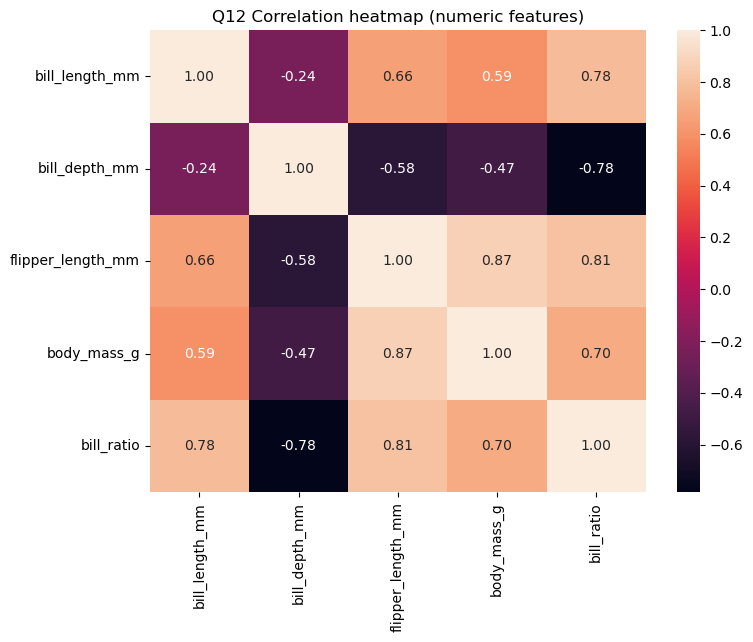

In [14]:
# Q12: Correlation matrix for numeric features + heatmap
num_only = df_clean.select_dtypes(include=[np.number])
corr = num_only.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Q12 Correlation heatmap (numeric features)")
plt.show()

In [15]:
# Q13: Define y=species, X=others except species, split with stratify
y = df_clean["species"]
X = df_clean.drop(columns=["species"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nQ13) Shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape, "y_train:", y_train.shape, "y_test:", y_test.shape)



Q13) Shapes:
X_train: (275, 7) X_test: (69, 7) y_train: (275,) y_test: (69,)


In [17]:
# Q14: Preprocessing pipeline (copy/paste as in PDF)
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [18]:
# Q15.1: KNN pipeline (n_neighbors=5), train, predict, accuracy
knn_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
print("\nQ15.1) KNN Accuracy:", knn_acc)

# Q15.2: Logistic Regression pipeline (max_iter=2000), train, predict, accuracy
logreg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

logreg_model.fit(X_train, y_train)
logreg_pred = logreg_model.predict(X_test)
logreg_acc = accuracy_score(y_test, logreg_pred)
print("Q15.2) Logistic Regression Accuracy:", logreg_acc)



Q15.1) KNN Accuracy: 0.9855072463768116
Q15.2) Logistic Regression Accuracy: 1.0


In [20]:
# Q16: Conclusion based on accuracy
print("\nQ16) Conclusion:")
if logreg_acc > knn_acc:
    print(f"- Logistic Regression performs better in terms of accuracy ({logreg_acc:.4f} > {knn_acc:.4f}).")
    print("- This suggests that a linear decision boundary (after one-hot encoding and scaling) fits the data better.")
elif knn_acc > logreg_acc:
    print(f"- KNN performs better in terms of accuracy ({knn_acc:.4f} > {logreg_acc:.4f}).")
    print("- This suggests that local neighborhood relationships capture the data structure more effectively.")
else:
    print(f"- Both models achieved the same accuracy ({knn_acc:.4f} == {logreg_acc:.4f}).")
    print("- In this case, you may choose the simpler/faster model or compare additional metrics such as F1-score or confusion matrix.")


Q16) Conclusion:
- Logistic Regression performs better in terms of accuracy (1.0000 > 0.9855).
- This suggests that a linear decision boundary (after one-hot encoding and scaling) fits the data better.


In [ ]:
categ_columns = df_copy[exclude="np.number"].columns
categ_colums.fill(mode)